In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss

In [10]:
df = pd.read_csv('../data/CORCCACBS.csv')


a = df.groupby(df['date'])['value'].mean().round(2)#.reset_index()
b = pd.to_datetime(df['date'].unique())
df= pd.DataFrame({
    'date':b,
    'value':a.values
})
df = df.set_index('date')

print(df.loc['2011':'2020'])


            value
date             
2011-01-01   6.95
2011-04-01   5.35
2011-07-01   5.75
2011-10-01   4.66
2012-01-01   4.29
2012-04-01   3.99
2012-07-01   3.86
2012-10-01   3.90
2013-01-01   3.75
2013-04-01   3.48
2013-07-01   3.34
2013-10-01   3.36
2014-01-01   3.26
2014-04-01   3.32
2014-07-01   3.06
2014-10-01   3.01
2015-01-01   2.95
2015-04-01   2.92
2015-07-01   2.94
2015-10-01   2.92
2016-01-01   3.06
2016-04-01   3.03
2016-07-01   3.05
2016-10-01   3.47
2017-01-01   3.47
2017-04-01   3.53
2017-07-01   3.57
2017-10-01   3.66
2018-01-01   3.67
2018-04-01   3.63
2018-07-01   3.65
2018-10-01   3.64
2019-01-01   3.69
2019-04-01   3.68
2019-07-01   3.71
2019-10-01   3.75
2020-01-01   3.75
2020-04-01   3.83
2020-07-01   3.56
2020-10-01   2.68


no time filtering

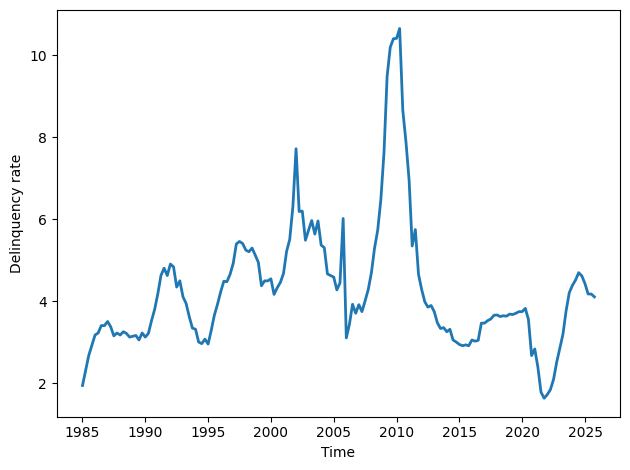

In [11]:
plt.plot(df, linewidth=2.0)
plt.ylabel('Delinquency rate')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [12]:
print(df.head())

            value
date             
1985-01-01   1.95
1985-04-01   2.31
1985-07-01   2.68
1985-10-01   2.93
1986-01-01   3.18


Let's map out only recent data - after 2011 to ignore the 2010 spike in D rates

In [13]:
df_filtered = df['2011-12':'2025-10']


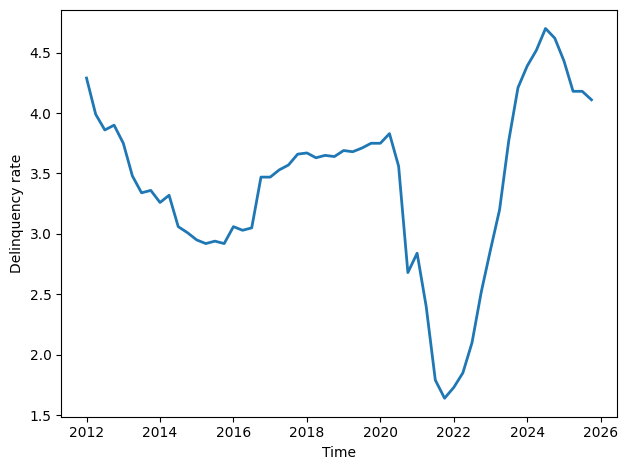

In [14]:
plt.plot(df_filtered, linewidth=2.0)
plt.ylabel('Delinquency rate')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

Beginning of 2022, most travel restrictions were lifted, will we see something like this soon? (travel restrictions?) dont think so not like we had in covid... do we think covid was the reason behind these drops? I personally think so but maybe it was something else 



Finding Rolling mean/std

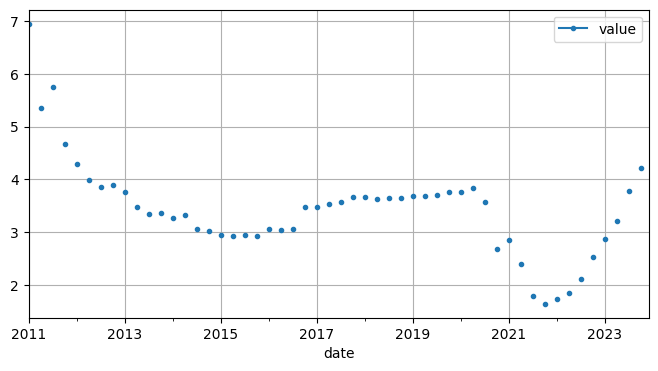

In [15]:
period=slice('2011','2023') #take out most recent years to avoid data snooping
df_monthly  = df.resample('ME').mean() #monthly mean
rolling_average = df_monthly[period].rolling(window=12).mean()



fig,ax = plt.subplots(figsize=(8,4))
df_monthly[period].plot(ax=ax,marker='.')
rolling_average.plot(ax=ax, grid=True, legend=False)
plt.show()

lets try a diff 

In [16]:
dff_diff = df_filtered.diff(1)
print(dff_diff.head(10))

            value
date             
2012-01-01    NaN
2012-04-01  -0.30
2012-07-01  -0.13
2012-10-01   0.04
2013-01-01  -0.15
2013-04-01  -0.27
2013-07-01  -0.14
2013-10-01   0.02
2014-01-01  -0.10
2014-04-01   0.06


## Stationary Tests (to formalize) ADF / KPSS

In [42]:
adf_p = adfuller(dff_diff.dropna())
print(f'ADF pvalue: {adf_p[1]}')

kpss_p = kpss(dff_diff.dropna(),regression='ct')
print(f'KPSS pvalue: {kpss_p[1]}')


if (adf_p[1] < 0.05) & (kpss_p[1] < 0.05): 
    print('ambigious')

elif (adf_p[1] < 0.05) & (kpss_p[1] > 0.05):
    print('Stationary, awwww yeahhhh')

elif (adf_p[1] > 0.05) & (kpss_p[1] < 0.05):
    print('non-stationary')

else:
    print('trend stationary')


ADF pvalue: 0.003228675521199678
KPSS pvalue: 0.1
Stationary, awwww yeahhhh


C:\Users\Marwa\AppData\Local\Temp\ipykernel_31104\2752638105.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(dff_diff.dropna(),regression='ct')


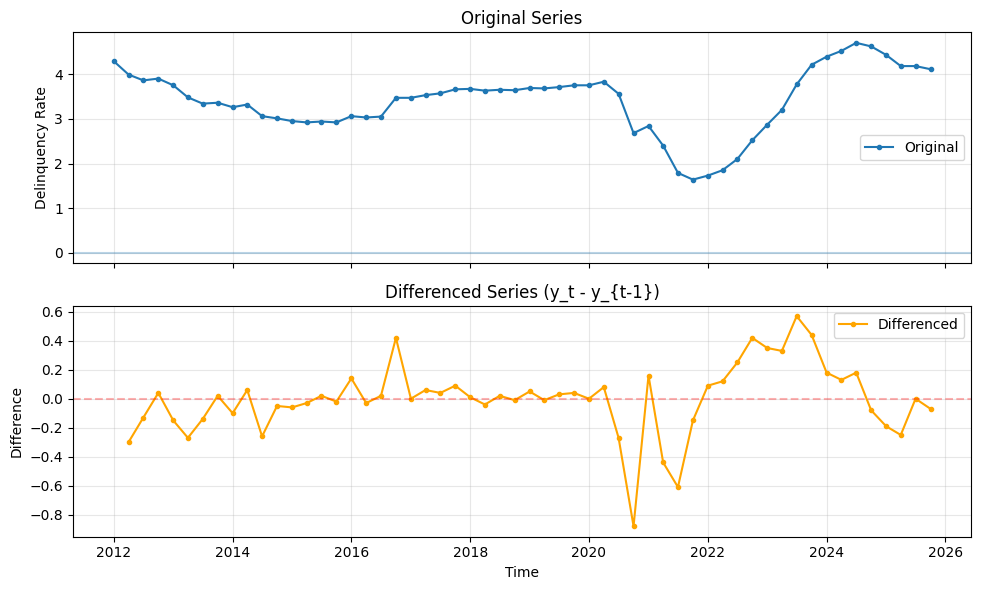

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Original series
ax1.plot(df_filtered, marker='.', linewidth=1.5, label='Original')
ax1.axhline(y=0,  alpha=0.3)
ax1.set_ylabel('Delinquency Rate')
ax1.set_title('Original Series')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Differenced series
ax2.plot(dff_diff, marker='.', linewidth=1.5, color='orange', label='Differenced')
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.3)
ax2.set_ylabel('Difference')
ax2.set_xlabel('Time')
ax2.set_title('Differenced Series (y_t - y_{t-1})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

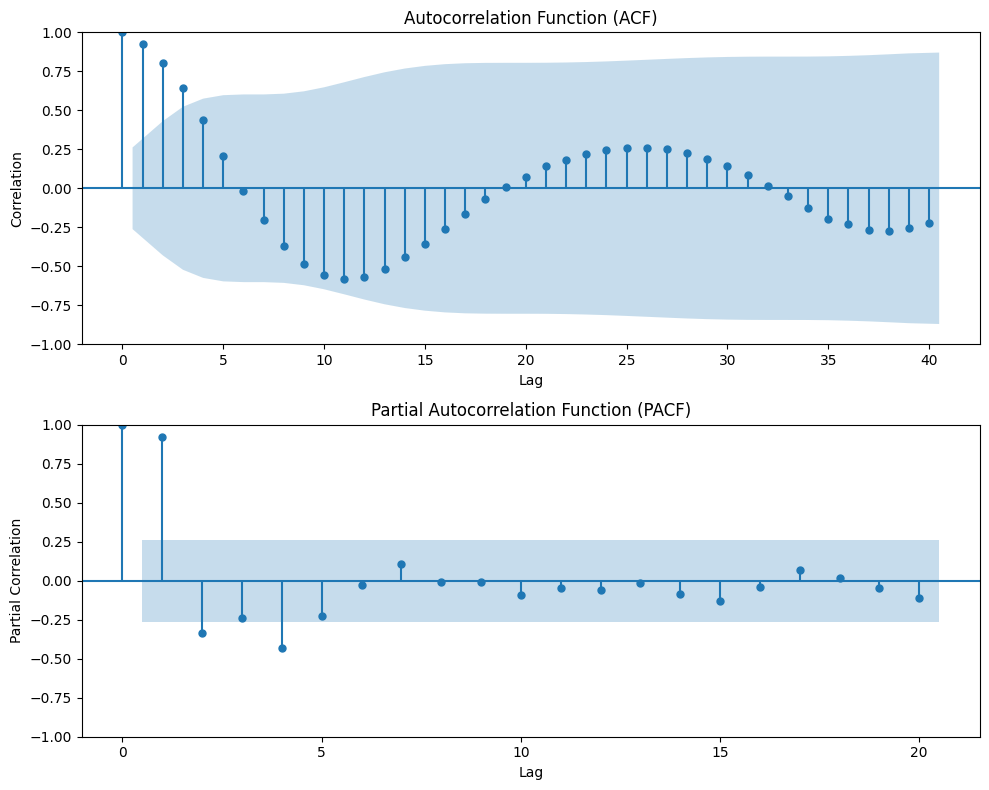

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10,8))


# ACF plot
plot_acf(df_filtered,lags=40,ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation')

# PACF plot
plot_pacf(df_filtered, lags=20, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Partial Correlation')

plt.tight_layout()
plt.show()

Outlier Analysis - lets take a closer look at 2021 to 2023 & what to do...

Based on this artical from the Federal Reserve: https://www.federalreserve.gov/econres/notes/feds-notes/a-note-on-recent-dynamics-of-consumer-delinquency-rates-20251124.html


if we look at the whole data as a whole from lets say 2000, world events disaster/epidemic do somewhat happen at a consistent pace... what I put those as a flag?

if we do kind of erase these events, delinquency rates are pretty stuck around 2-4.5%


In [71]:
threshold_top =4.5 
threshold_bottom = 2

crossed_above = (df.value > threshold_top) & (df.value.shift(1) <= threshold_top)

crossed_below = (df.value < threshold_bottom) & (df.value.shift(1) >= threshold_bottom)

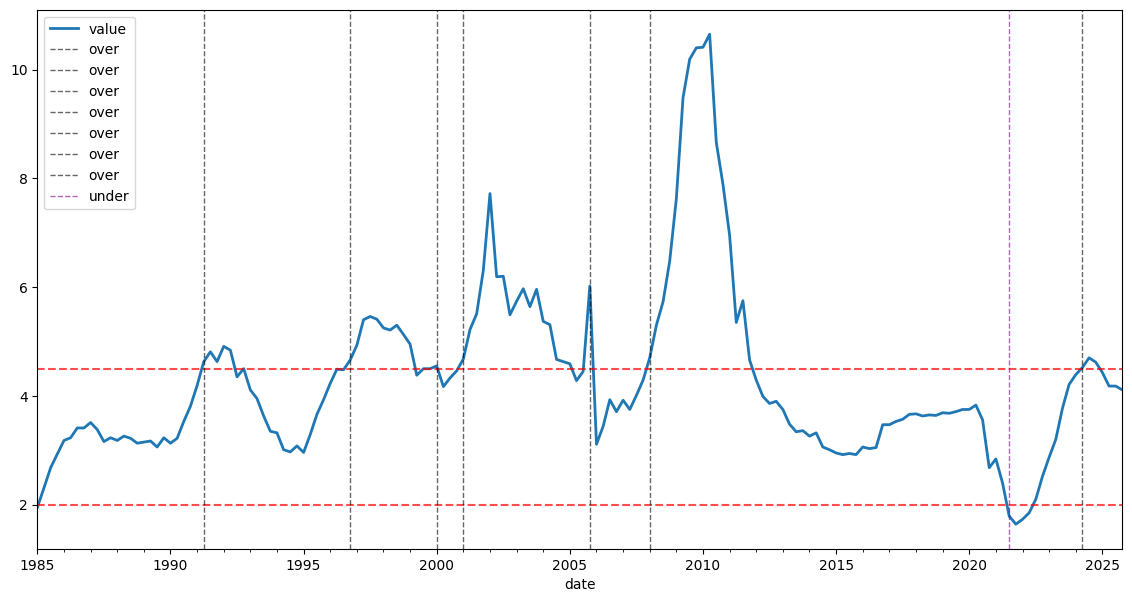

In [83]:
fig, ax = plt.subplots(figsize=(14, 7))

df.plot(ax=ax, linewidth=2, legend=False)
ax.axhline(y=threshold_bottom, linestyle='--', color='r', alpha=0.7)
ax.axhline(y=threshold_top, linestyle='--', color='r', alpha=0.7)


for date in df.index[crossed_above]:
    ax.axvline(x=date, linestyle='--', color='black', alpha=0.6, linewidth=1,label='over')
for date in df.index[crossed_below]:
    ax.axvline(x=date, linestyle='--', color='purple', alpha=0.6, linewidth=1,label="under")

plt.legend()
plt.show()

In [18]:
# These dont make sense just yet..... we need to forecast first
print(f'Mean absolute Error of') 
print(f'Mean absolute percentage Error:% ')


Mean absolute Error of
Mean absolute percentage Error:% 
